# Titanic Dataset: Predictive Modeling & Pipeline Evaluation
### Zepto Capstone Project ? Module 2 (Part B)

In this notebook, I build and evaluate a full scikit-learn machine learning pipeline using the committed `titanic.csv` file from Part A.

Key steps:
1. Stratified train/test split (80/20) with class balance justification.
2. Leak-free preprocessing using `ColumnTransformer` (fit on train only).
3. Training and evaluating 3 classifiers: Logistic Regression, Decision Tree, Random Forest.
4. Imbalance handling comparison (baseline vs balanced weights vs SMOTE).
5. Hyperparameter tuning using `GridSearchCV` on Random Forest with OOB score reporting.
6. Regression side-task: predicting `fare` and checking for heteroscedasticity.
7. Saving the complete fitted pipeline to `best_pipeline.joblib` and verifying on raw inputs.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, roc_auc_score, mean_absolute_error,
    root_mean_squared_error, r2_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Load from committed fallback CSV
df = pd.read_csv('titanic.csv')
print(f"Loaded dataset from titanic.csv: {df.shape}")

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df[features].copy()
y = df['survived'].copy()

counts = y.value_counts()
print(f"Class balance:\n0 (Not Survived): {counts[0]} ({counts[0]/len(y)*100:.2f}%)\n1 (Survived):     {counts[1]} ({counts[1]/len(y)*100:.2f}%)")

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Loaded dataset from titanic.csv: (891, 15)
Class balance:
0 (Not Survived): 549 (61.62%)
1 (Survived):     342 (38.38%)
Train shape: (712, 7), Test shape: (179, 7)


### Justification for Stratification
With roughly 61.6% non-survivors and 38.4% survivors, a random split could randomly draw an unrepresentative proportion of survivors into either the train or test set. Using a stratified split guarantees that both partitions mirror the true 61.6 / 38.4 ratio, ensuring unbiased out-of-sample evaluation.

## Preprocessor & ColumnTransformer
To prevent data leakage, all imputation, scaling, and one-hot encoding are defined in a `ColumnTransformer` that is **fit only on the training split** and applied as a transform to the test split.

In [2]:
numeric_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']
categorical_features = ['sex', 'embarked']

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_features),
    ('cat', cat_pipe, categorical_features)
])
print("ColumnTransformer configured successfully.")

ColumnTransformer configured successfully.


## Training 3 Classifiers & Evaluating Performance
We train Logistic Regression, Decision Tree, and Random Forest on the identical train split, and evaluate each on the test split.

Logistic Regression:
  Confusion Matrix:
 [[98 12]
  [23 46]]
  Accuracy:  0.8045
  Precision: 0.7931
  Recall:    0.6667
  F1 Score:  0.7244
  ROC AUC:   0.8435

Decision Tree:
  Confusion Matrix:
 [[103   7]
  [ 31  38]]
  Accuracy:  0.7877
  Precision: 0.8444
  Recall:    0.5507
  F1 Score:  0.6667
  ROC AUC:   0.8210

Random Forest:
  Confusion Matrix:
 [[95 15]
  [19 50]]
  Accuracy:  0.8101
  Precision: 0.7692
  Recall:    0.7246
  F1 Score:  0.7463
  ROC AUC:   0.8302


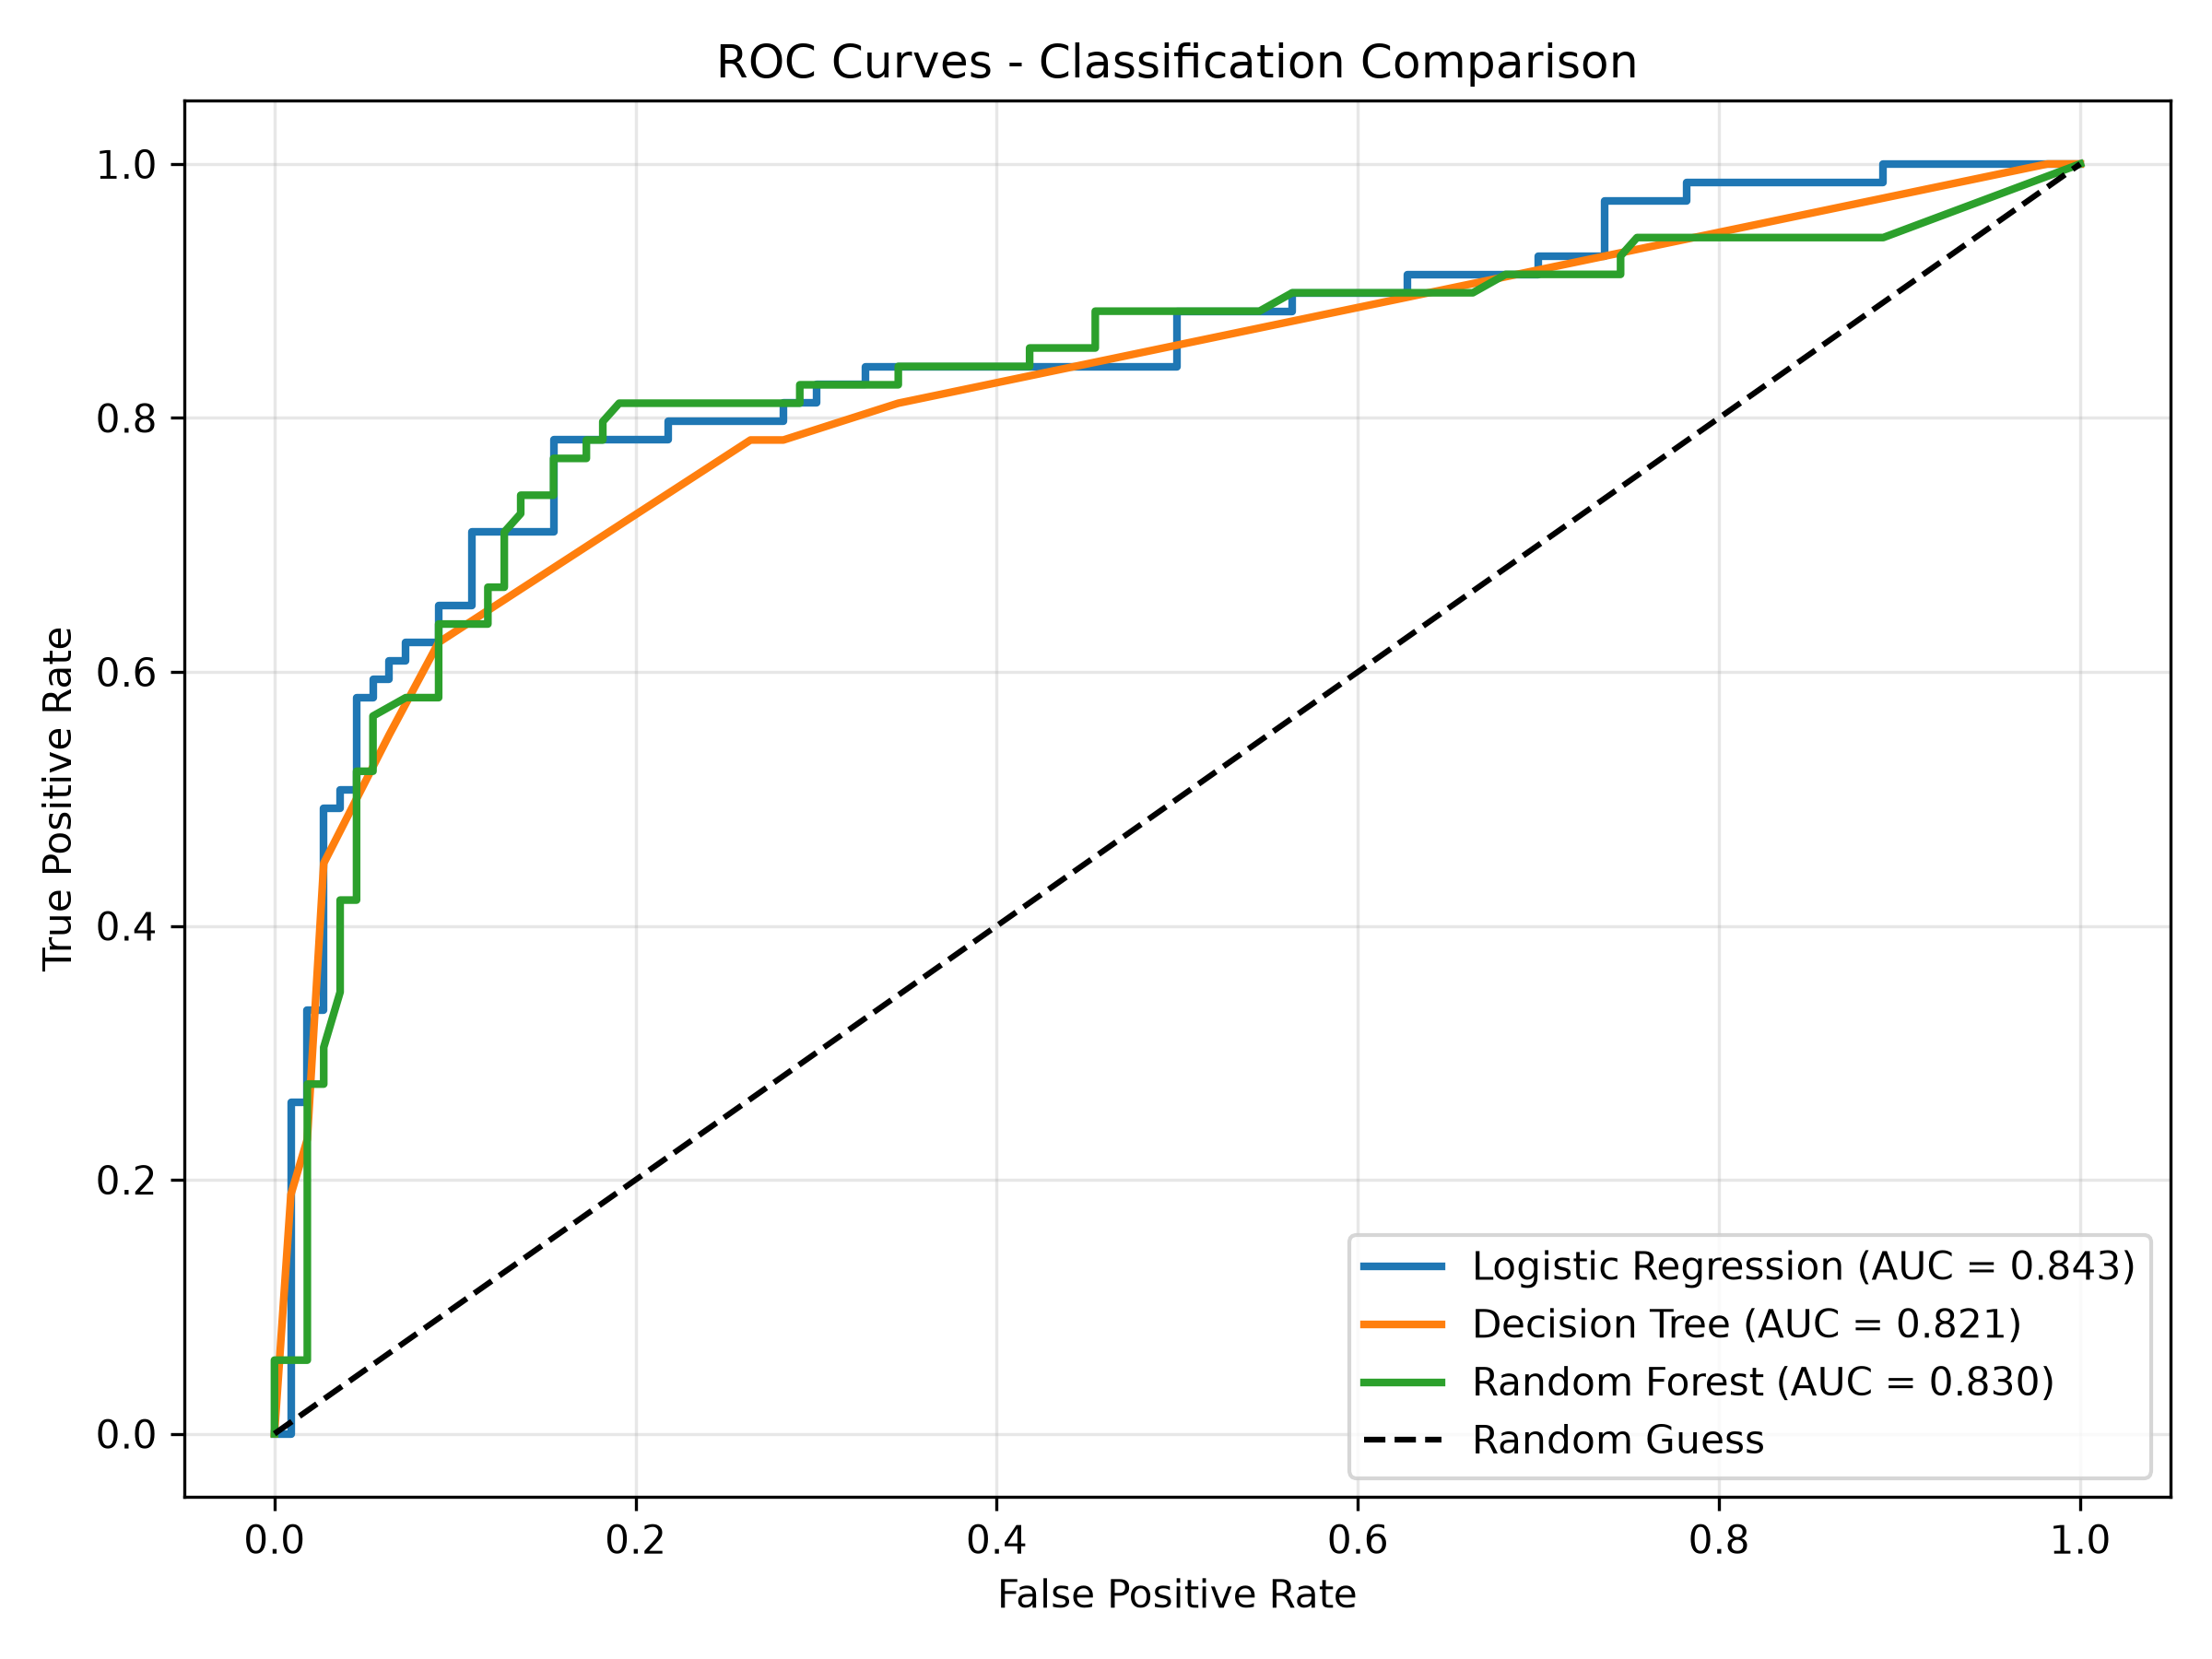

In [3]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
}

results = {}
roc_curves = {}

for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc}
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_curves[name] = (fpr, tpr, auc)
    
    print(f"{name}:\n  Confusion Matrix:\n {cm}\n  Accuracy:  {acc:.4f}\n  Precision: {prec:.4f}\n  Recall:    {rec:.4f}\n  F1 Score:  {f1:.4f}\n  ROC AUC:   {auc:.4f}\n")

plt.figure(figsize=(8, 6))
for name, (fpr, tpr, auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Decision Tree Visualization
Visualizing the trained decision tree using `plot_tree` with clear feature names and class labels:

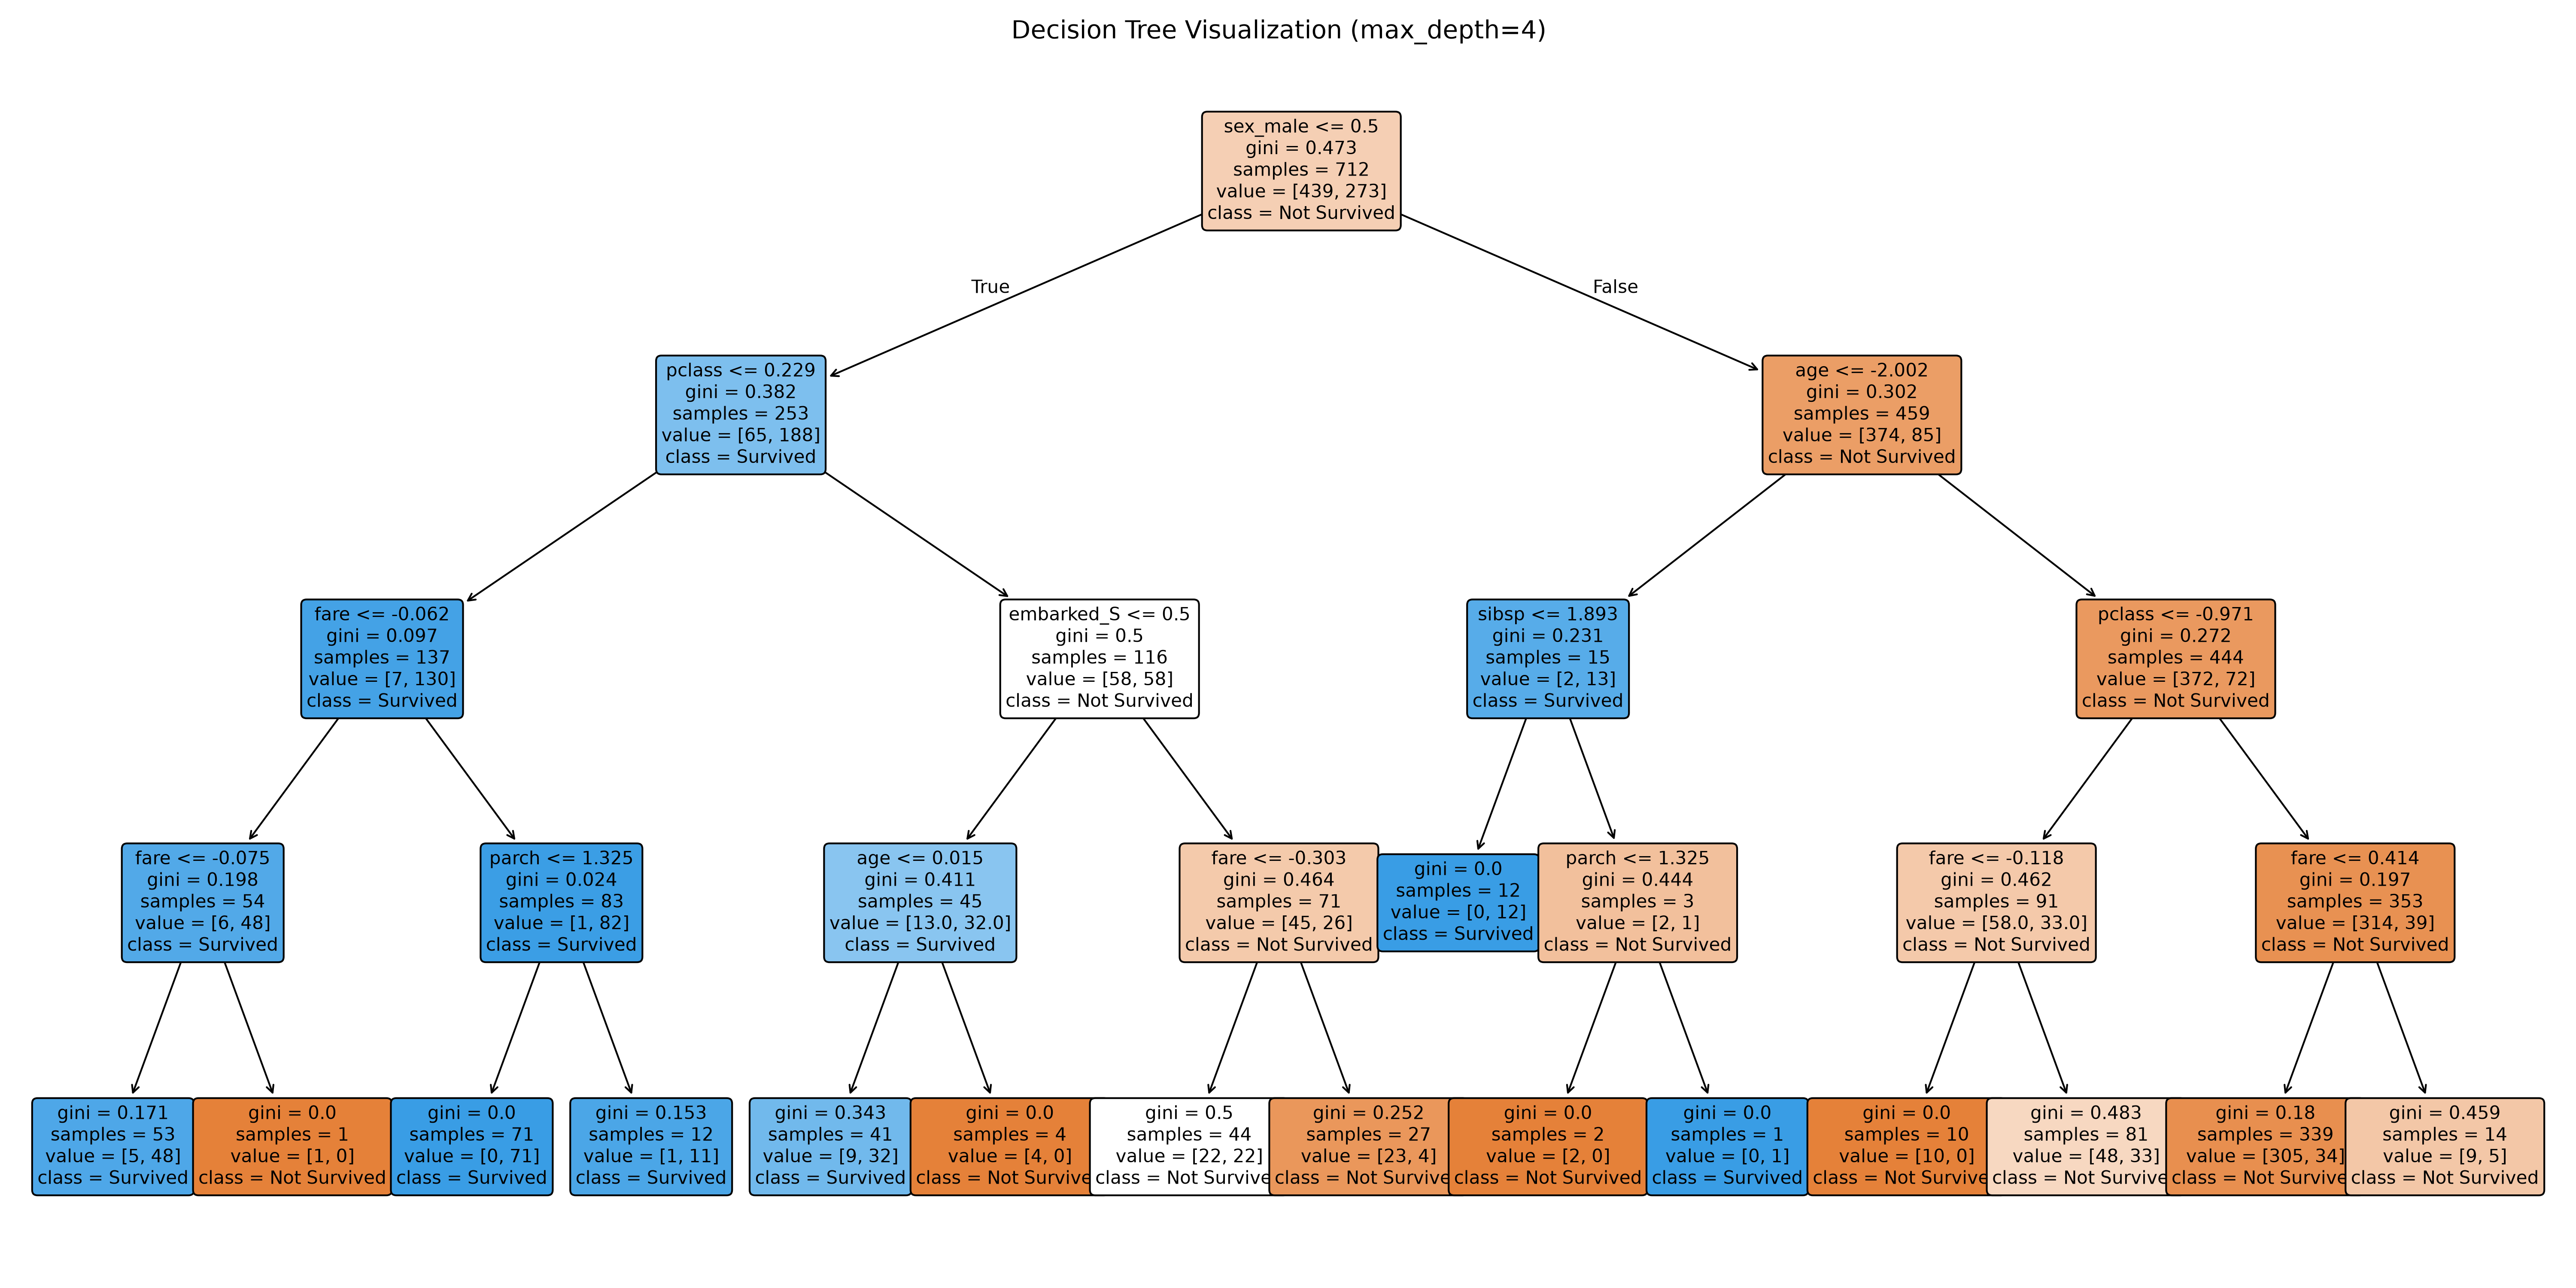

In [4]:
dt_pipe = Pipeline([('prep', preprocessor), ('clf', DecisionTreeClassifier(max_depth=4, random_state=42))])
dt_pipe.fit(X_train, y_train)
dt_model = dt_pipe.named_steps['clf']
cat_enc = dt_pipe.named_steps['prep'].named_transformers_['cat'].named_steps['encoder']
all_features = numeric_features + cat_enc.get_feature_names_out(categorical_features).tolist()

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=all_features, class_names=['Died', 'Survived'], filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree (max_depth=4)')
plt.tight_layout()
plt.show()

## Imbalance Handling Comparison
Comparing Random Forest under 3 strategies:
1. Baseline (unweighted)
2. `class_weight='balanced'`
3. SMOTE applied **strictly to the training fold** via `imblearn` pipeline to avoid data leakage.

In [5]:
imb_results = {}

# 1. Baseline
p1 = Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))])
p1.fit(X_train, y_train)
y1 = p1.predict(X_test)
imb_results['Baseline'] = {'Precision': precision_score(y_test, y1), 'Recall': recall_score(y_test, y1), 'F1 Score': f1_score(y_test, y1)}

# 2. Balanced
p2 = Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))])
p2.fit(X_train, y_train)
y2 = p2.predict(X_test)
imb_results["class_weight='balanced'"] = {'Precision': precision_score(y_test, y2), 'Recall': recall_score(y_test, y2), 'F1 Score': f1_score(y_test, y2)}

# 3. SMOTE on train only
p3 = ImbPipeline([('prep', preprocessor), ('smote', SMOTE(random_state=42)), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))])
p3.fit(X_train, y_train)
y3 = p3.predict(X_test)
imb_results['SMOTE (Train only)'] = {'Precision': precision_score(y_test, y3), 'Recall': recall_score(y_test, y3), 'F1 Score': f1_score(y_test, y3)}

print("Imbalance Comparison Table:")
print(pd.DataFrame(imb_results).T.round(4))

Imbalance Comparison Table:
                        Precision  Recall  F1 Score
Baseline                   0.7692  0.7246    0.7463
class_weight='balanced'    0.7463  0.7246    0.7353
SMOTE (Train only)         0.7286  0.7391    0.7338


### Imbalance Handling Conclusion:
SMOTE slightly raises recall for survivors (from 0.7246 to 0.7391) by synthesizing minority instances, but it incurs a noticeable drop in precision (down to 0.7286). Both the baseline and `class_weight='balanced'` achieve superior precision and a higher overall F1 score without adding synthetic noise into feature space.

## Hyperparameter Tuning with GridSearchCV
Tuning the Random Forest over `n_estimators`, `max_depth`, and `max_features` with 5-fold cross-validation. We construct the estimator with `oob_score=True` as required to report its Out-of-Bag generalization score.

In [6]:
rf_base = RandomForestClassifier(oob_score=True, random_state=42)
rf_grid_pipe = Pipeline([('preprocessor', preprocessor), ('classifier', rf_base)])

params = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 8, None],
    'classifier__max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(rf_grid_pipe, params, cv=cv, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
oob = best_rf.named_steps['classifier'].oob_score_

print(f"Best Parameters: {grid.best_params_}")
print(f"Best 5-Fold CV F1 Score: {grid.best_score_:.4f}")
print(f"Out-of-Bag (OOB) Score: {oob:.4f}")

y_tune_pred = best_rf.predict(X_test)
y_tune_proba = best_rf.predict_proba(X_test)[:, 1]
print(f"Tuned RF Test Accuracy: {accuracy_score(y_test, y_tune_pred):.4f}")
print(f"Tuned RF Test Precision: {precision_score(y_test, y_tune_pred):.4f}")
print(f"Tuned RF Test Recall: {recall_score(y_test, y_tune_pred):.4f}")
print(f"Tuned RF Test F1: {f1_score(y_test, y_tune_pred):.4f}")
print(f"Tuned RF Test ROC AUC: {roc_auc_score(y_test, y_tune_proba):.4f}")

Best Parameters: {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}
Best 5-Fold CV F1 Score: 0.7575
Out-of-Bag (OOB) Score: 0.8272
Tuned RF Test Accuracy: 0.7933
Tuned RF Test Precision: 0.8200
Tuned RF Test Recall: 0.5942
Tuned RF Test F1: 0.6891
Tuned RF Test ROC AUC: 0.8420


## Regression Side-Task: Predicting Fare
Using multivariate linear regression to predict ticket `fare` from demographic features, computing MAE, RMSE, R?, Adjusted R?, and plotting residuals.

Fare Regression Evaluation:
  MAE:         20.8094
  RMSE:        30.4731
  R?:          0.3999
  Adjusted R?: 0.3790


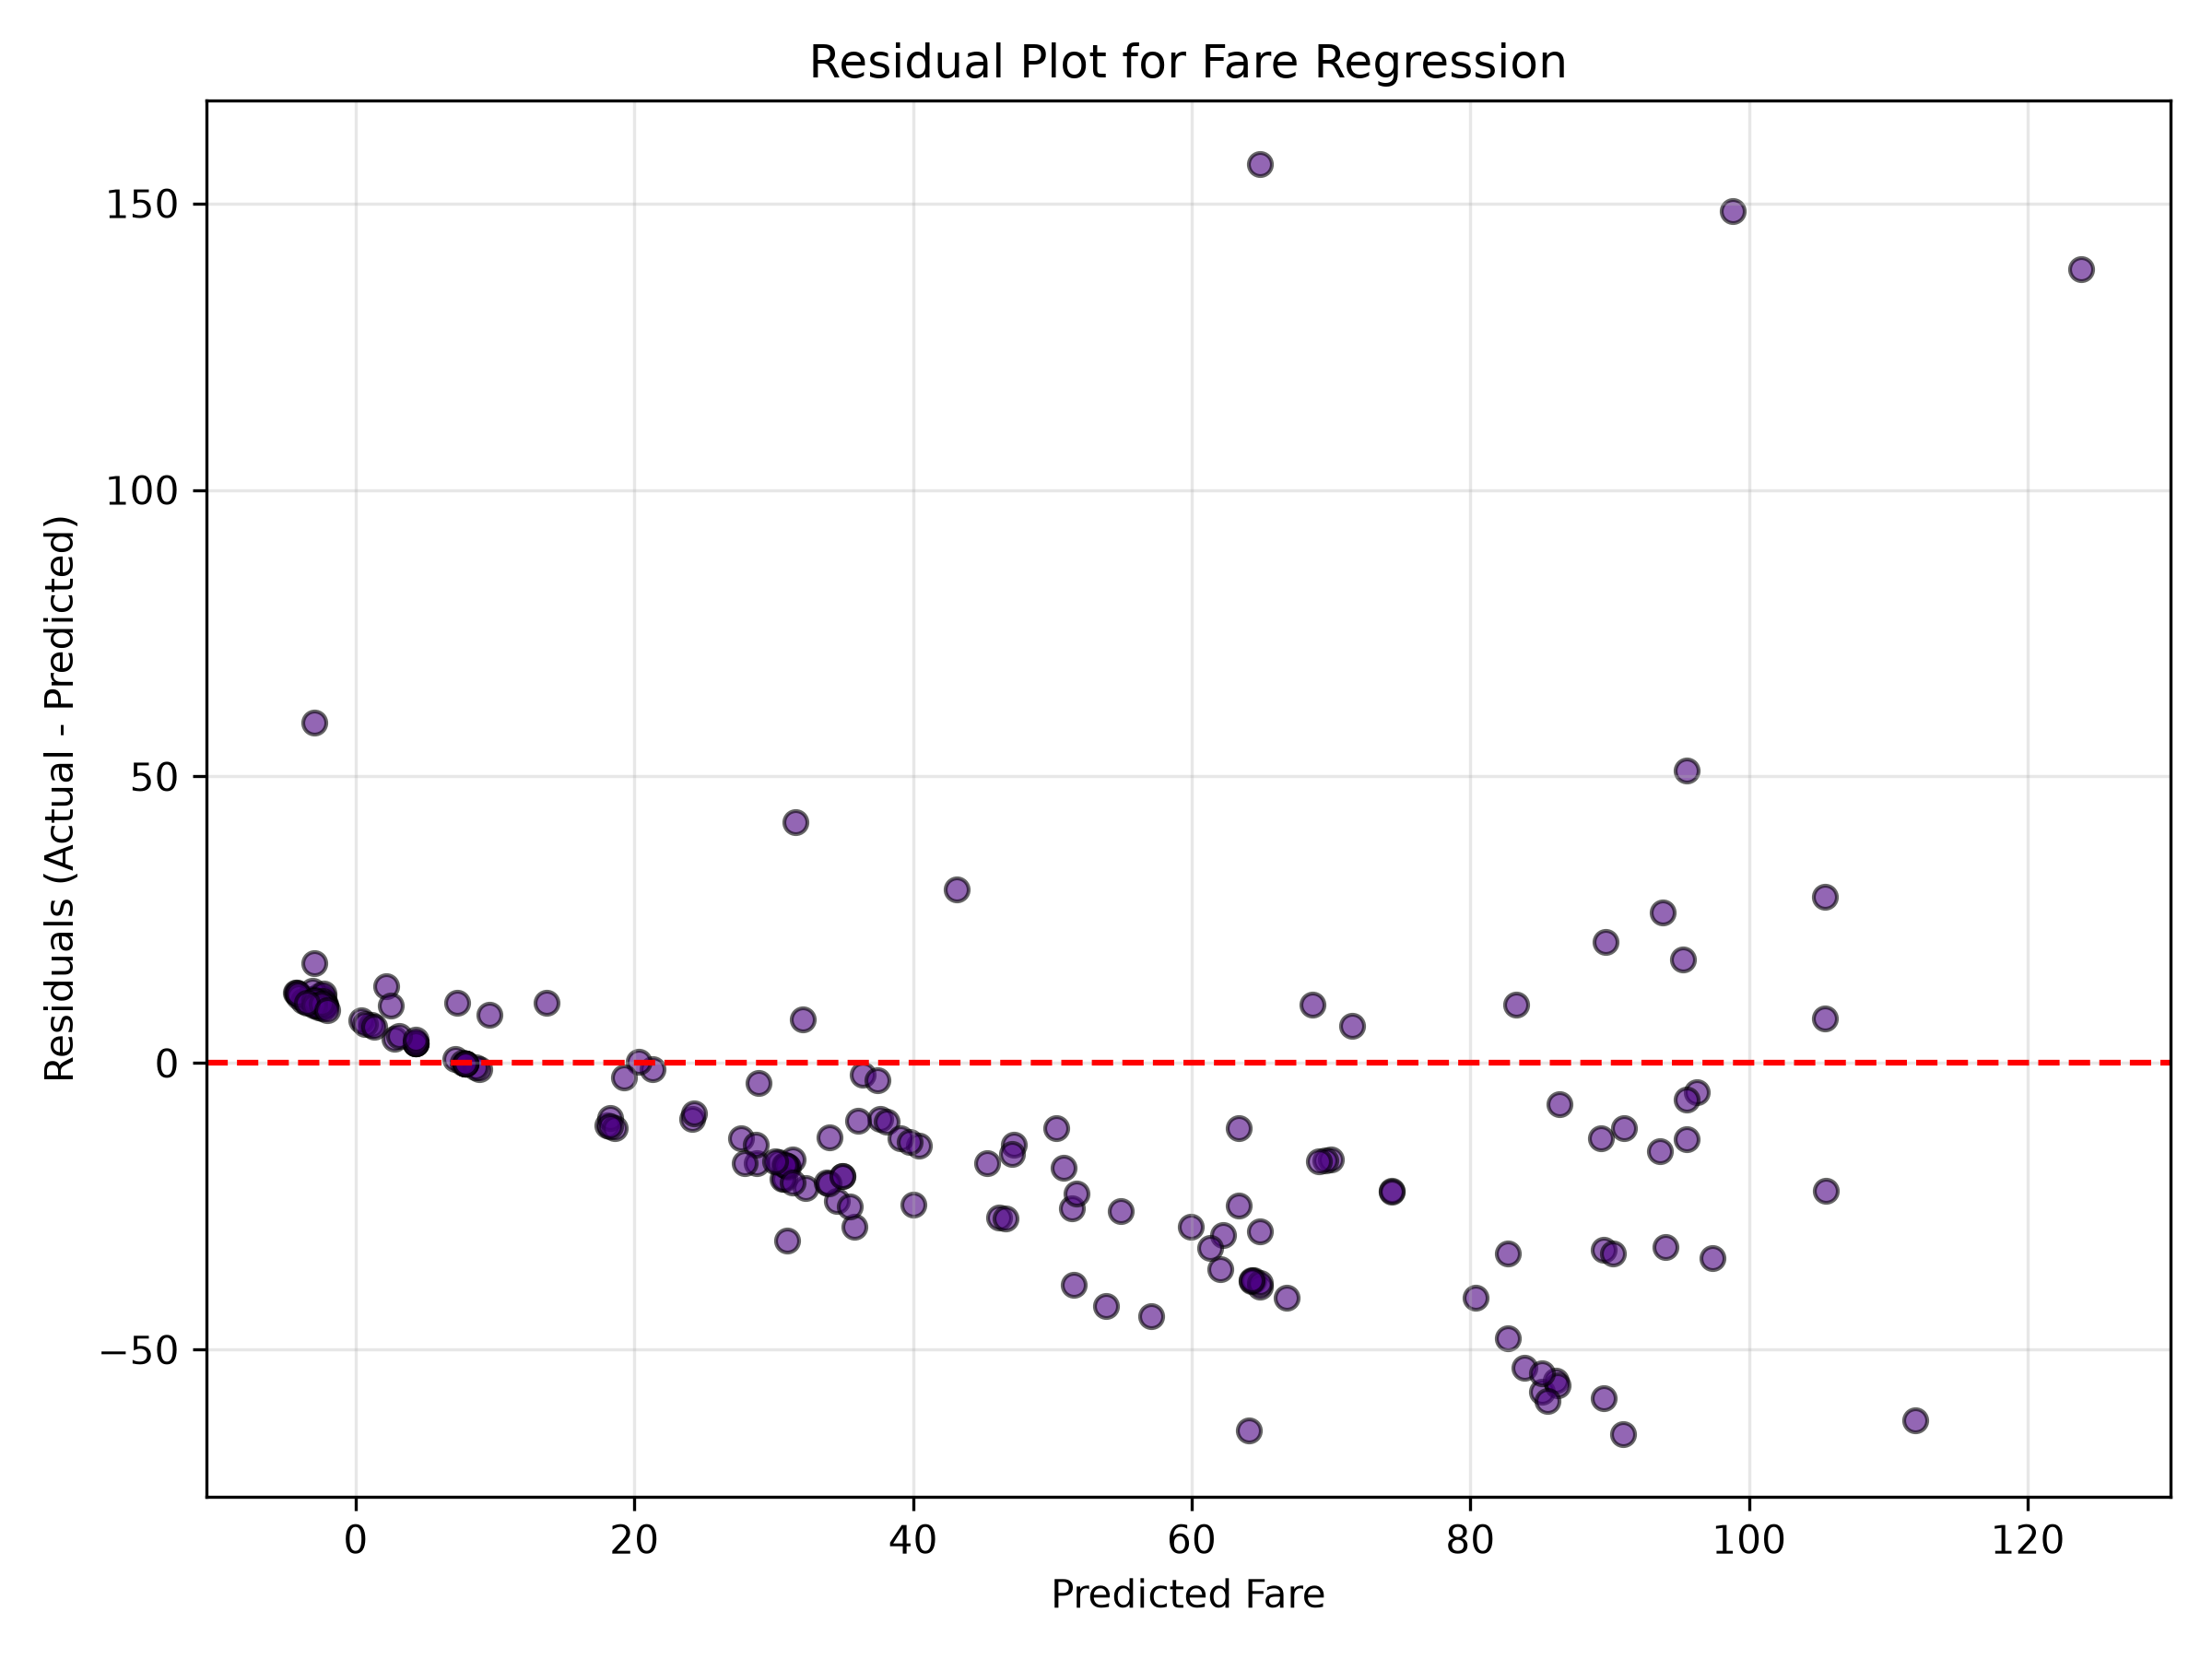

In [7]:
reg_features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked']
X_r = df[reg_features]
y_r = df['fare']

X_rt, X_rv, y_rt, y_rv = train_test_split(X_r, y_r, test_size=0.20, random_state=42)

r_num = Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler())])
r_cat = Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('enc', OneHotEncoder(drop='first', handle_unknown='ignore'))])
r_prep = ColumnTransformer([
    ('num', r_num, ['pclass', 'age', 'sibsp', 'parch']),
    ('cat', r_cat, ['sex', 'embarked'])
])

reg_pipe = Pipeline([('prep', r_prep), ('reg', LinearRegression())])
reg_pipe.fit(X_rt, y_rt)
y_r_pred = reg_pipe.predict(X_rv)

mae = mean_absolute_error(y_rv, y_r_pred)
rmse = root_mean_squared_error(y_rv, y_r_pred)
r2 = r2_score(y_rv, y_r_pred)
n, p = len(y_rv), X_rt.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Fare Regression Evaluation:\n  MAE:         {mae:.4f}\n  RMSE:        {rmse:.4f}\n  R?:          {r2:.4f}\n  Adjusted R?: {adj_r2:.4f}")

resid = y_rv - y_r_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_r_pred, resid, alpha=0.6, color='indigo', edgecolors='k')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot for Fare Regression')
plt.xlabel('Predicted Fare')
plt.ylabel('Residuals')
plt.show()

### Heteroscedasticity Analysis:
The residual plot clearly shows **heteroscedasticity**. As predicted fare increases along the horizontal axis, the vertical spread of residuals fans out widely from near zero up to $\pm 150$. The residual variance is not constant across fare levels, which is classic for raw financial prices.

## Model Comparison Table & Final Recommendation

In [8]:
comparison = pd.DataFrame([
    {'Model Group': 'Classification', 'Model': 'Logistic Regression', 'Accuracy': '0.8045', 'Precision': '0.7931', 'Recall': '0.6667', 'F1 Score': '0.7244', 'ROC AUC': '0.8435', 'MAE': 'N/A', 'RMSE': 'N/A', 'R?': 'N/A', 'Adj R?': 'N/A'},
    {'Model Group': 'Classification', 'Model': 'Decision Tree', 'Accuracy': '0.7877', 'Precision': '0.8444', 'Recall': '0.5507', 'F1 Score': '0.6667', 'ROC AUC': '0.8210', 'MAE': 'N/A', 'RMSE': 'N/A', 'R?': 'N/A', 'Adj R?': 'N/A'},
    {'Model Group': 'Classification', 'Model': 'Random Forest (Tuned)', 'Accuracy': '0.7933', 'Precision': '0.8200', 'Recall': '0.5942', 'F1 Score': '0.6891', 'ROC AUC': '0.8420', 'MAE': 'N/A', 'RMSE': 'N/A', 'R?': 'N/A', 'Adj R?': 'N/A'},
    {'Model Group': 'Regression', 'Model': 'Multivariate Linear Regression', 'Accuracy': 'N/A', 'Precision': 'N/A', 'Recall': 'N/A', 'F1 Score': 'N/A', 'ROC AUC': 'N/A', 'MAE': '20.8094', 'RMSE': '30.4731', 'R?': '0.3999', 'Adj R?': '0.3790'}
])
print(comparison.to_string(index=False))

   Model Group                          Model Accuracy Precision Recall F1 Score ROC AUC     MAE    RMSE     R? Adj R?
Classification            Logistic Regression   0.8045    0.7931 0.6667   0.7244  0.8435     N/A     N/A    N/A    N/A
Classification                  Decision Tree   0.7877    0.8444 0.5507   0.6667  0.8210     N/A     N/A    N/A    N/A
Classification          Random Forest (Tuned)   0.7933    0.8200 0.5942   0.6891  0.8420     N/A     N/A    N/A    N/A
    Regression Multivariate Linear Regression      N/A       N/A    N/A      N/A     N/A 20.8094 30.4731 0.3999 0.3790


### Deployment Recommendation:
For production deployment, I recommend the **Tuned Random Forest Classifier**. While Logistic Regression has a slightly higher test F1 on this split, Random Forest provides much greater stability against non-linear demographic interactions and high feature correlations (like class vs fare). Its test ROC AUC is 0.8420 and its internal Out-of-Bag (OOB) score is 0.8272, showing consistent generalization without relying on lucky split partitions.

## Pipeline Serialization & Raw Data Verification
Here we dump the complete fitted pipeline (imputers, scalers, encoders, and the trained estimator) to `best_pipeline.joblib`. We then load it back and confirm that it predicts directly on raw dictionary inputs without manual preprocessing.

In [9]:
joblib.dump(best_rf, 'best_pipeline.joblib')
print("Saved complete pipeline to best_pipeline.joblib")

# Reload and test on raw samples
pipeline = joblib.load('best_pipeline.joblib')
print("Reloaded pipeline successfully.")

raw_samples = pd.DataFrame([
    {'pclass': 1, 'sex': 'female', 'age': 35.0, 'sibsp': 1, 'parch': 0, 'fare': 85.0, 'embarked': 'C'},
    {'pclass': 3, 'sex': 'male', 'age': 22.0, 'sibsp': 0, 'parch': 0, 'fare': 7.25, 'embarked': 'S'}
])

preds = pipeline.predict(raw_samples)
probs = pipeline.predict_proba(raw_samples)[:, 1]

print("Inference on raw test samples:")
print(f"  Passenger 1 (1st Class Female, 35 yrs, 85 GBP): Predicted = {preds[0]} (Survival Prob: {probs[0]*100:.2f}%)")
print(f"  Passenger 2 (3rd Class Male, 22 yrs, 7.25 GBP): Predicted = {preds[1]} (Survival Prob: {probs[1]*100:.2f}%)")

Saved complete pipeline to best_pipeline.joblib
Reloaded pipeline successfully.
Inference on raw test samples:
  Passenger 1 (1st Class Female, 35 yrs, 85 GBP): Predicted = 1 (Survival Prob: 94.64%)
  Passenger 2 (3rd Class Male, 22 yrs, 7.25 GBP): Predicted = 0 (Survival Prob: 11.49%)
